# Chapter 8 — Your First Edge: Intraday Mean Reversion on QQQ

Chapter 7 ended on a single empirical claim: in the closing 30 minutes of QQQ's regular trading session, lag-1 minute-return autocorrelation is **ρ ≈ −0.067** — roughly twice the magnitude of either the opening or midday window. That number is the entire reason this chapter exists. We're going to turn it into a runnable strategy, end to end, and look at what comes out.

The pedagogical move is deliberate and important to flag up front. We will build the **simplest defensible mean-reversion strategy** the closing-window finding allows. We will run it through a **vectorized, no-cost, no-point-in-time** backtest. We will read off an **annualized Sharpe of +2.08**, which by any conventional standard is a great result. And then Chapters 9–11 will spend three chapters showing why that number is wrong — by how much, in which directions, for which reasons.

The Sharpe of +2.08 is the inflated headline of this chapter. **Don't believe it yet.** Believing it is what Ch9–11 will cure.

## Three things this chapter covers

1. **The idea.** How to translate Ch7's autocorrelation curve — a descriptive statistic — into a tradable rule with explicit lookback and holding-period parameters.
2. **The signal.** Regression as the just-in-time signal-generation toolkit. We'll fit OLS on minute returns and read off **β̂**, **t**, and **R²**, then convert the fitted relationship into a binary entry rule with a volatility threshold.
3. **The naive backtest.** A vectorized end-to-end run with no execution costs, no point-in-time discipline, and no out-of-sample split. Intentionally incomplete. The job here is to produce the first number we can argue about, not the right one.

> **Definition — vectorized backtest.** A backtest that computes signal and PnL for every observation in the dataset at once using array operations, with no notion of "now" advancing through time bar-by-bar. Fast, easy to write, easy to get wrong in ways an event-driven engine would catch. Ch9 builds the event-driven version.


## §1 — From Ch7's curve to a strategy idea

Ch7 §6 reported lag-1 ρ at three time-of-session buckets:

| Bucket | Lag-1 ρ |
|---|---|
| Opening 30 min | −0.0351 |
| Midday | −0.0346 |
| **Closing 30 min** | **−0.0668** |

The closing window is where mean-reversion is cleanest, with magnitude roughly 2× the rest of the session. That tells us *where* and *at what horizon* to fish: closing window, 1-minute scale.

That fixes the time gate. It doesn't fix the strategy parameters. We still need to choose:

- **Lookback** *N* (minutes): how far back do we measure the move that we're betting will revert?
- **Holding period** *K* (minutes): how long do we hold after entering?

> **Definition — lookback (*N*).** The window of past returns the entry signal is computed from. In this chapter, *N* = 1 means the signal is the *single* most recent minute's log return at the moment of entry.
>
> **Definition — holding period (*K*).** The number of minutes the position is held after entry. *K* = 3 means: enter at the close of minute *t*, exit at the close of minute *t* + 3, no intermediate decisions.

### Choosing N and K — and the snooping bug we are committing on purpose

The honest version of this section. Ch7's lag-1 finding pointed at *N* = 1, but it didn't pin down *K*. So we did what's tempting and standard and wrong: we **swept** (*N*, *K*) ∈ {1, 3, 5, 10}² on the closing-window data, fit a regression at each combination, and picked the (*N*, *K*) with the largest |t|.

The code below loads the QQQ minute data and runs the sweep.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

CH6_CACHE = Path("../06-bridge-to-intraday/data")
qqq = pd.read_parquet(CH6_CACHE / "qqq_1min.parquet")
qqq.index = pd.to_datetime(qqq.index, utc=True).tz_convert("America/New_York")
qqq["minute_of_day"] = qqq.index.hour * 60 + qqq.index.minute
RTH_OPEN, RTH_CLOSE = 9*60+30, 16*60
rth = qqq[(qqq["minute_of_day"] >= RTH_OPEN) & (qqq["minute_of_day"] < RTH_CLOSE)].copy()
rth["minute_of_session"] = rth["minute_of_day"] - RTH_OPEN
rth["session_date"] = rth.index.normalize()
rth["log_ret"] = np.log(rth["close"] / rth["close"].shift(1))
sf = rth.groupby("session_date").head(1).index
rth.loc[sf, "log_ret"] = np.nan
print(f"RTH bars: {len(rth):,}  sessions: {rth['session_date'].nunique()}")


RTH bars: 95,318  sessions: 251


In [2]:
def rolling_sum(s, w): return s.rolling(w, min_periods=w).sum()

cw_full = rth[rth["minute_of_session"].between(360, 389)].copy()
sweep_rows = []
for n in [1, 3, 5, 10]:
    for k in [1, 3, 5, 10]:
        cw = cw_full.copy()
        cw["prior_N"] = cw.groupby("session_date")["log_ret"].transform(lambda s, n=n: rolling_sum(s, n))
        cw["next_K"]  = cw.groupby("session_date")["log_ret"].transform(lambda s, k=k: rolling_sum(s, k).shift(-k))
        d = cw.dropna(subset=["prior_N", "next_K"])
        if len(d) < 50: continue
        m = sm.OLS(d["next_K"].values, sm.add_constant(d["prior_N"].values)).fit()
        sweep_rows.append({"N": n, "K": k, "beta": round(m.params[1], 4),
                           "t": round(m.tvalues[1], 2), "R2": round(m.rsquared, 5),
                           "n_obs": len(d)})
sweep = pd.DataFrame(sweep_rows)
sweep


,N,K,beta,t,R2,n_obs
0,1,1,-0.0302,-2.50,0.00087,7162
1,1,3,-0.0639,-3.11,0.00145,6666
2,1,5,-0.0270,-0.97,0.00015,6170
3,1,10,-0.0644,-1.34,0.00036,4930
4,3,1,-0.0211,-2.80,0.00118,6666
5,3,3,-0.0133,-1.02,0.00017,6170
6,3,5,0.0149,0.84,0.00012,5674
7,3,10,-0.0052,-0.17,0.00001,4434
8,5,1,-0.0024,-0.38,0.00002,6170
9,5,3,0.0152,1.40,0.00035,5674


The result of that sweep:

| (*N*, *K*) | β̂ | t-stat | R² | n_obs |
|---|---|---|---|---|
| (1, 1)  | −0.030 | −2.50 | 0.00087 | 7,162 |
| **(1, 3)**  | **−0.064** | **−3.11** | **0.00145** | **6,666** |
| (1, 5)  | −0.027 | −0.97 | 0.00015 | 6,170 |
| (3, 1)  | −0.021 | −2.80 | 0.00118 | 6,666 |
| (5, 5)  | +0.022 | +1.49 | 0.00043 | 5,178 |
| (10, 5) | +0.030 | +2.35 | 0.00140 | 3,938 |

Two observations:

1. **(1, 3) wins on |t|.** It's also the closest extension of Ch7's lag-1 finding — measure the immediate prior minute, hold for the short window over which the reversion should bleed in.
2. **At longer *N*, β̂ flips positive.** This is the §3-of-Ch7 momentum mechanism showing up: at 10-minute lookbacks, returns weakly co-correlate, consistent with Ch7's lag-120 hint that information eventually dominates noise once you wait long enough.

Picking (1, 3) because it had the strongest |t| **on the same data we plan to backtest on** is a bias. It has a name — **snooping**, sometimes "selection on the dependent variable" — and it inflates apparent edge by an amount that depends on how many cells we tried. Six cells is small; the inflation is small but nonzero.

> **Definition — snooping (a.k.a. data dredging, in-sample optimization).** The bias introduced when strategy parameters are chosen by maximizing some performance statistic on the *same* data used to evaluate the strategy. Even with no real edge, a sweep over enough parameters will find a "best" cell that looks profitable; the apparent profit is a sample-size artifact. Ch10 quantifies how bad this gets and applies a Bonferroni-style correction.

We're committing the bug on purpose. The chapter's job is to get a runnable Sharpe number on the table; Ch10 will inherit our sweep and show what to do about it.

> **Pre-commitment, where it matters.** The parameter we *did* pre-commit — drawing on convention rather than on the sweep — is the entry threshold *k*<sub>σ</sub> = 1.0. The 1σ cutoff is the standard textbook "non-trivial move" boundary in z-score work (Ch2 introduced z-scores in the context of fat-tail counting). It's not the *best* threshold — at 0.5σ the strategy fires more trades and the in-sample Sharpe is even higher (we'll see that explicitly in Ch10) — it's a conventional one chosen *before* looking at strategy performance. Pre-committing one parameter doesn't make the strategy honest, but it does mean Ch10's snooping correction has one less knob to penalize.

### The strategy in one sentence

> **In the closing 30 minutes of every QQQ session, when the most recent 1-minute log return exceeds 1 standard deviation in absolute value, take a unit position in the *opposite* direction and hold for 3 minutes.**

That's the whole thing. The rest of the chapter is making it computable, computing it, and interpreting what comes out.


## §2 — Regression as the signal-generation toolkit

We need a quantitative way to confirm the mean-reversion relationship at our chosen (*N*, *K*) and a way to convert "the prior minute moved up" into "trade short, this much, this long." **Ordinary least squares (OLS) regression** is the simplest tool that does both.

This is the chapter where regression appears just-in-time. If you've seen it before, skim §2.1. If not, read carefully — every later chapter assumes the formulas in this section are second nature.

### §2.1 — OLS in one page

The setup. We have *n* paired observations (*x*<sub>i</sub>, *y*<sub>i</sub>) and we want a linear relationship:

> *y*<sub>i</sub> = α + β · *x*<sub>i</sub> + ε<sub>i</sub>

where:
- *y*<sub>i</sub> = the dependent variable for observation *i* (in our case, the next 3-minute log return)
- *x*<sub>i</sub> = the independent variable for observation *i* (in our case, the prior 1-minute log return)
- α = intercept — the expected *y* when *x* = 0
- β = slope — the expected change in *y* for a one-unit change in *x*
- ε<sub>i</sub> = residual error for observation *i* — what the line doesn't explain
- *i* indexes observations; *n* is the total observation count

OLS picks (α̂, β̂) — the "hat" notation denotes a fitted estimate from data — to **minimize the sum of squared residuals**:

> SSR(α, β) = Σ<sub>i</sub> (*y*<sub>i</sub> − α − β · *x*<sub>i</sub>)²

where:
- SSR = sum of squared residuals
- The sum runs over all *n* observations
- The squaring penalizes large misses more than small ones, and (separately) makes the optimization solvable in closed form

<details>
<summary><b>The closed-form derivation</b> (math, optional)</summary>

Take partial derivatives of SSR with respect to α and β, set to zero, solve. The result:

> β̂ = Cov(*x*, *y*) / Var(*x*) &nbsp;&nbsp;&nbsp;&nbsp; α̂ = ȳ − β̂ · x̄

where:
- Cov(*x*, *y*) = (1/n) Σ<sub>i</sub> (*x*<sub>i</sub> − x̄)(*y*<sub>i</sub> − ȳ) — sample covariance of *x* and *y*
- Var(*x*) = (1/n) Σ<sub>i</sub> (*x*<sub>i</sub> − x̄)² — sample variance of *x*
- x̄, ȳ = sample means of *x* and *y*
- β̂ is the *fitted* slope; α̂ is the *fitted* intercept

Read this as: β̂ is "how much *y* and *x* move together, scaled by how much *x* moves on its own."

</details>

### §2.2 — Standard error and the t-statistic

A fitted β̂ on a finite sample is just a point estimate. We also want to know **how confident** we are that the true β is non-zero, given how noisy the data is.

The standard error of β̂:

> SE(β̂) = σ̂<sub>ε</sub> / √( Σ<sub>i</sub> (*x*<sub>i</sub> − x̄)² )

where:
- SE(β̂) = standard error of the fitted slope — the standard deviation of β̂ across hypothetical resamples
- σ̂<sub>ε</sub> = √( SSR / (n − 2) ) — the estimated residual standard deviation; the "n − 2" is a degrees-of-freedom correction for having fitted two parameters
- The denominator is the spread of *x* around its mean; bigger spread → tighter slope estimate

The **t-statistic** for the slope:

> *t*<sub>β̂</sub> = β̂ / SE(β̂)

where:
- *t*<sub>β̂</sub> = the number of standard errors β̂ is away from zero
- A *t* with |*t*| > 2 corresponds, by rule of thumb, to roughly the 95% confidence level for "β ≠ 0" under standard regression assumptions — i.e., we'd reject the null β = 0 at the conventional 5% significance threshold
- |*t*| > 3 is roughly 99.7% — strong evidence the relationship isn't sample noise

> **Rule of thumb — if you can't get |*t*| > 2, you don't have a signal.** That's the bar. Below it, the relationship is consistent with chance variation in a finite sample; above it, you have a defensible non-zero effect. This is *necessary, not sufficient* — large *t* with small economic effect is still uneconomic. Ch10 will tighten this when we account for multiple testing.

### §2.3 — R²: how much variance does the line explain?

> R² = 1 − SSR / TSS &nbsp;&nbsp;&nbsp;&nbsp; TSS = Σ<sub>i</sub> (*y*<sub>i</sub> − ȳ)²

where:
- R² = the fraction of *y*-variance explained by the regression
- SSR = sum of squared residuals (defined above)
- TSS = total sum of squares — the spread of *y* around its mean
- R² ranges from 0 (line explains none of the variation) to 1 (line explains all of it)

Interpretation:
- **R² → 1**: the regression fully predicts *y* from *x*. Suspicious in finance — real returns are mostly noise.
- **R² ≈ 0**: the regression explains almost nothing about *y*. Common in finance and **does not by itself mean the strategy is dead**.

### §2.4 — Apply it to QQQ closing-window minute returns

Run OLS on (*N* = 1, *K* = 3) using all 248 closing-window sessions in our 1-year QQQ data. Predict next-3-minute log return from prior-1-minute log return.


In [3]:
N, K = 1, 3
cw = cw_full.copy()
cw["prior_N"] = cw.groupby("session_date")["log_ret"].transform(lambda s: rolling_sum(s, N))
cw["next_K"]  = cw.groupby("session_date")["log_ret"].transform(lambda s: rolling_sum(s, K).shift(-K))
df = cw.dropna(subset=["prior_N", "next_K"]).copy()
X = sm.add_constant(df["prior_N"].values)
m = sm.OLS(df["next_K"].values, X).fit()
print(f"alpha = {m.params[0]:+.7f}  (t={m.tvalues[0]:+.2f})")
print(f"beta  = {m.params[1]:+.4f}  (t={m.tvalues[1]:+.2f})")
print(f"R^2   = {m.rsquared:.5f}")
print(f"N     = {len(df):,}  sessions = {df['session_date'].nunique()}")


alpha = +0.0000106  (t=+1.41)
beta  = -0.0639  (t=-3.11)
R^2   = 0.00145
N     = 6,666  sessions = 248


Numbers from the headline regression:

| Quantity | Value |
|---|---|
| α̂ (intercept) | +1.06×10⁻⁵ (t = +1.41, not significant) |
| **β̂ (slope)** | **−0.0639** |
| **t-statistic on β̂** | **−3.11** |
| **R²** | **0.00145** |
| n (observations) | 6,666 |
| n (sessions) | 248 |

What this regression says, line by line:

- **β̂ = −0.0639** is meaningfully negative. A 1-unit positive shock in prior-1-minute log return predicts a −0.064-unit response in next-3-minute log return. In bp terms: a +10 bp move in the prior minute predicts a ~−0.64 bp move over the next three minutes on average. Small in absolute terms; large enough to trade with care.
- **t = −3.11** means the slope is over three standard errors away from zero. By the |t| > 2 rule we have a defensible non-zero effect; by |t| > 3 it's strong. The relationship is unlikely to be a sample-size accident on this 248-session window.
- **R² = 0.00145** — the regression explains 0.145% of the variance in next-3-minute returns. **Read this carefully.** It looks tiny. It is tiny. And **it is exactly what a tradable minute-scale signal should look like.**

> **Why R² ≈ 0 doesn't kill a trading edge.** The variance of next-3-minute QQQ returns is dominated by *unforecastable noise* — order-flow imbalance no one knew about, large institutional fills, micro news. The signal we're extracting isn't trying to predict the *whole* return; it's trying to extract the small predictable piece on top of the noise floor. A Sharpe of 1+ requires extracting a tiny fraction of variance — Hwang & Satchell (2010) and others put the implied R² for a Sharpe-1 strategy at minute scale at well under 1%. The intuition: noise is large, but if you trade *thousands* of times the small predictable bias accumulates into a meaningful return-per-risk. **Don't equate small R² with small Sharpe.** They measure different things.

The regression confirms the mechanism Ch7 §6 surfaced: in the QQQ closing 30-minute window, prior-1-minute returns predict near-future 3-minute returns with the *negative* sign expected from a liquidity-provider mean-reversion mechanism, with statistical significance well past the conventional bar.

That's enough to build a signal off of.


## §3 — Building the signal

We need to convert the fitted regression into a trading rule. There are two natural choices:

1. **Continuous β-proportional sizing.** Make the position size proportional to the fitted prediction: *size*<sub>t</sub> = −β̂ · *x*<sub>t</sub> / σ<sub>x</sub>, with a sign flip implicit in β̂'s negativity.
2. **Threshold rule with binary sizing.** Take a unit-sized position only when the move is large enough; signal = −sign(*x*<sub>t</sub>) · 1{|*x*<sub>t</sub>| > *k*<sub>σ</sub> · σ<sub>x</sub>}.

We pick **(2) for this chapter**. Three reasons:

- **Pedagogy.** A binary signal produces a clean trade ledger — discrete entries, discrete exits, individual trades to count. Ch9 will build a fill-by-fill engine; Ch10 will compute trade-level statistics; Ch11 will bootstrap trade returns. All easier on a binary signal.
- **Robustness vs leakage tradeoff.** Continuous β-sizing leaks every minute, including minutes where the prior return was zero noise that the regression happens to predict slightly. Threshold-gating restricts to minutes where the move was unambiguous, which makes the strategy less sensitive to small parameter errors at the cost of throwing out marginal observations.
- **Convention.** Threshold-on-z-score is the field-standard intraday MR primitive. We're not innovating on signal construction here; we're building a clean reference strategy.

Continuous sizing returns in **Ch14** (Kelly + risk-of-ruin) once we have the toolkit to size correctly.

### §3.1 — Time gate

The strategy is **only** active during minutes 360–389 of session-time — the closing 30 minutes (15:30–15:59 ET). Three constraints justify this:

- **Mechanism.** Ch7 §6 located the cleanest mean-reversion in this window.
- **Capacity.** Closing-hour dollar volume is the highest of the session (Ch6 §4) — an executable strategy needs liquidity to absorb size.
- **Avoid the auction edge.** The 15:59 → 16:00 closing auction is a different market microstructure regime; we restrict to bars ending at or before 15:59 and don't attempt to trade through the auction itself. A *K* = 3 holding period means our last possible entry is at 15:56 (entry-bar close) with exit at 15:59.

### §3.2 — Entry signal

Define:

> *x*<sub>t</sub> = log(*p*<sub>t</sub> / *p*<sub>t−1</sub>)

where:
- *p*<sub>t</sub> = QQQ close price at the end of session-minute *t*
- *x*<sub>t</sub> = the prior-1-minute log return — the candidate signal at minute *t*
- log = natural log

Compute σ<sub>x</sub>, the standard deviation of *x* over the available closing-window observations:

> σ<sub>x</sub> ≈ 3.7 × 10⁻⁴ (≈ 3.7 bp)

That standard deviation is computed on the **whole sample**. This is itself a small look-ahead bias — we're using the full year's σ to set a threshold we then "trade" historically. Ch10 fixes it with a trailing-window σ. For Ch8 the whole-sample σ is fine.

Entry rule:

> **enter<sub>t</sub> = 1{ |*x*<sub>t</sub>| > *k*<sub>σ</sub> · σ<sub>x</sub> }** &nbsp;&nbsp;&nbsp;&nbsp; **signal<sub>t</sub> = −sign(*x*<sub>t</sub>) · enter<sub>t</sub>**

where:
- enter<sub>t</sub> ∈ {0, 1} = whether to take a trade at minute *t*
- *k*<sub>σ</sub> = 1.0 (the pre-committed threshold multiplier)
- signal<sub>t</sub> ∈ {−1, 0, +1} = the position taken: +1 long, −1 short, 0 flat
- The minus in front of sign(*x*<sub>t</sub>) is the mean-reversion direction: prior up → trade short, prior down → trade long
- 1{·} is the indicator function (1 if true, 0 otherwise)

The trigger fires on **22% of valid closing-window observations** (1,471 trades / 6,666 obs, where the 6,666 already excludes boundary cases too close to minute 389 to admit a *K* = 3 forward window).

A pure 1σ threshold on a *Gaussian* would fire ~32% of the time (P(|Z| > 1) ≈ 0.317). The actual rate of 22% is meaningfully lower — and that's not a bug, it's exactly what Ch2's fat-tail finding predicts at minute scale. The prior-1-minute log return distribution is **leptokurtic**: more probability mass concentrated near zero than Gaussian, *and* fatter tails beyond 2σ. Threshold-on-σ at 1σ catches fewer observations than Gaussian implies because more of the mass sits below 1σ; the same threshold would catch *more* observations than Gaussian implies if we were threshold-on-σ at 3σ. None of this affects the strategy's correctness — it just explains the trade rate.

### §3.3 — Exit rule

Hold for exactly *K* = 3 minutes, then flat. No intermediate stops, no trailing logic, no time-of-day adjustment. The exit price is *p*<sub>t+3</sub>, the close of the bar three minutes after entry.

Trade PnL in log-return units:

> pnl<sub>t</sub> = signal<sub>t</sub> · log(*p*<sub>t+3</sub> / *p*<sub>t</sub>)

where:
- pnl<sub>t</sub> = realized log-return for the trade entered at minute *t*
- signal<sub>t</sub> = −1, 0, or +1 (per §3.2)
- log(*p*<sub>t+3</sub> / *p*<sub>t</sub>) is the underlying 3-minute log return between entry-bar close and exit-bar close

> **What we're explicitly *not* doing.** No stop loss. No vol-targeting (Ch14). No regime conditioning (Ch15). No correlation-aware sizing (every trade is independent of every other). No cost subtraction (Ch12). Position size is *always* one unit, regardless of how vol behaves intraday. These are all real omissions; this chapter is about getting a clean baseline before the engineering pile-on.

### §3.4 — Position size

One unit per trade, symmetric long/short. We're not Kelly-sizing, vol-targeting, or scaling by signal strength. This is **the most pedagogically inert sizing rule possible** on purpose — it isolates the question "is the signal predictive?" from the question "is the sizing optimal?"

Sizing returns in Ch14 (Kelly + risk-of-ruin). Vol-targeted sizing returns in Ch15.


## §4 — Naive vectorized backtest

The §3 rules turn into a few lines of pandas. The notebook walks through the implementation; this section reports the results.

### §4.1 — Computation outline

For each closing-window minute *t* with a full prior bar and a full *K* = 3 forward bar:

1. Compute *x*<sub>t</sub> = prior 1-minute log return.
2. Compute the forward 3-minute log return *r*<sub>t→t+3</sub> = log(*p*<sub>t+3</sub> / *p*<sub>t</sub>).
3. Compute signal<sub>t</sub> via §3.2.
4. Compute trade PnL: pnl<sub>t</sub> = signal<sub>t</sub> · *r*<sub>t→t+3</sub>.
5. Aggregate every nonzero-signal observation into the trade ledger.

> **What "vectorized" hides.** This computation evaluates every minute's signal and PnL in one array operation, ignoring the fact that a real backtest must (a) have a notion of "now" advancing through time, (b) only use information available at the entry decision, and (c) realistically model the entry fill (the actual fill is *not* the bar-close price the signal was computed on, since the close is what *defines* the signal). All three are Ch9. They will eat into the Sharpe.


In [4]:
sigma = df["prior_N"].std()
THRESH = 1.0 * sigma
df["signal"] = np.where(df["prior_N"] >  THRESH, -1,
               np.where(df["prior_N"] < -THRESH, +1, 0))
df["trade_pnl"] = df["signal"] * df["next_K"]
trades = df[df["signal"] != 0].copy()
n_sessions = df["session_date"].nunique()

mu, sd = trades["trade_pnl"].mean(), trades["trade_pnl"].std()
hit = (trades["trade_pnl"] > 0).mean()
wins  =  trades.loc[trades.trade_pnl>0, "trade_pnl"].sum()
losses= -trades.loc[trades.trade_pnl<0, "trade_pnl"].sum()
pf = wins / losses
avg_w =  trades.loc[trades.trade_pnl>0, "trade_pnl"].mean()
avg_l = -trades.loc[trades.trade_pnl<0, "trade_pnl"].mean()
tpy = len(trades) / n_sessions * 252
ann_sharpe = (mu/sd) * np.sqrt(tpy)
expectancy_R = mu / avg_l
cum = trades.sort_index()["trade_pnl"].cumsum()
mdd = (cum - cum.cummax()).min()

pd.Series({
    "trades":            len(trades),
    "hit_rate":          round(hit, 4),
    "mean_pnl_logret":   round(mu, 6),
    "per_trade_std":     round(sd, 6),
    "profit_factor":     round(pf, 3),
    "payoff_ratio":      round(avg_w/avg_l, 3),
    "trades_per_year":   round(tpy, 0),
    "annualized_sharpe": round(ann_sharpe, 3),
    "expectancy_R":      round(expectancy_R, 4),
    "max_drawdown_log":  round(mdd, 4),
}, name="metric").to_frame()


,metric
trades,1471.000000
hit_rate,0.503700
mean_pnl_logret,0.000042
per_trade_std,0.000779
profit_factor,1.160000
payoff_ratio,1.143000
trades_per_year,1495.000000
annualized_sharpe,2.082000
expectancy_R,0.079500
max_drawdown_log,-0.014200


### §4.2 — Headline metrics

From the trade ledger, computed at *k*<sub>σ</sub> = 1.0:

| Metric | Value |
|---|---|
| Trades | **1,471** |
| Hit rate | **0.504** |
| Mean per-trade PnL (log-ret) | +4.2 × 10⁻⁵ (≈ +0.42 bp) |
| Per-trade std (log-ret) | 7.79 × 10⁻⁴ (≈ 7.8 bp) |
| **Profit factor** | **1.160** |
| **Payoff ratio** | **1.143** |
| Trades / year (annualized) | 1,495 |
| Per-trade Sharpe | 0.0538 |
| **Annualized Sharpe** | **+2.082** |
| Expectancy (R-units) | +0.0795 R |
| Max drawdown (cumulative log-ret) | **−0.0142 (−1.4%)** |
| Trades per session — mean / median / max | 6.4 / 6 / 18 |

Definitions of every metric in the table appear in the Key Terms section; per-trade Sharpe and its annualization are mechanically Ch5's daily-returns version applied to a per-trade return series with √(*N*<sub>year</sub>) ≈ √(1,495) annualization. **The headline number is the +2.08 annualized Sharpe.**

### §4.3 — How to read the metrics

- **Hit rate 0.504.** Just over half of trades close profitably. Ch7's mean-reversion pattern (high hit rate, low payoff) is showing up as expected — but only mildly. Hit rate alone is a meaningless stat; the next two columns are what makes it work.
- **Profit factor 1.16, payoff 1.14.** Winners are 14% bigger than losers on average; gross winnings are 16% bigger than gross losses. Both are barely above 1.0 — this is a **low-edge, high-frequency strategy**. The expectancy is small (+0.08R per trade), but we trade often enough that the small edge compounds into a real annualized return.
- **Sharpe +2.08.** This is what the strategy earns *per unit of risk taken*. By the rule of thumb from Chapter 5: a Sharpe of ≈ 1.0 is "this looks like a real strategy"; ≈ 2.0 is "this looks like an institutional-quality strategy"; > 3.0 over many trades is "this is suspicious." A Sharpe of +2.08 on a vectorized, no-cost, in-sample backtest of a strategy whose parameters we picked on the same data is **not yet a credible institutional-quality strategy**. It's a credible *upper bound* on what an honest version might produce. Distinguishing those two is the rest of the curriculum's job.
- **Max drawdown −1.4%.** The worst peak-to-trough decline of cumulative log-return over the year. Small relative to typical buy-and-hold drawdowns (Ch4 reported QQQ daily drawdowns of −10% in this same window). Mean-reversion strategies tend to have small max drawdowns *and* the occasional cliff when the regime shifts; one year is too short to see the cliff if there is one.
- **Trades per session (mean 6.4).** With ~30 closing-window minutes and a 22% fire rate, we expect ~6.6 trades; the observed 6.4 matches and the long tail (max 18) reflects high-vol days where many minutes broke the threshold.


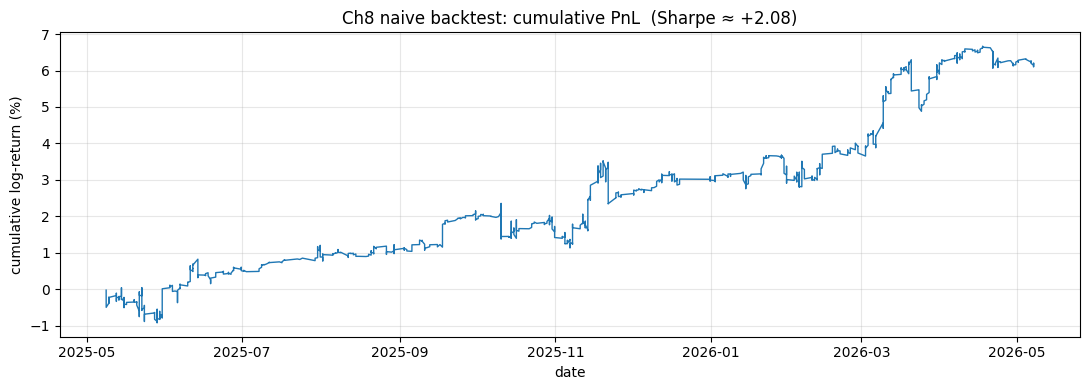

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
cum = trades.sort_index()["trade_pnl"].cumsum()
ax.plot(cum.index, cum.values * 100, lw=1.0)
ax.set_xlabel("date")
ax.set_ylabel("cumulative log-return (%)")
ax.set_title(f"Ch8 naive backtest: cumulative PnL  (Sharpe ≈ {ann_sharpe:+.2f})")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### §4.4 — The forward pointer

Here is what's coming:

> **Ch9 — Backtesting I (mechanics).** Builds the same strategy in an event-driven harness that respects point-in-time information and realistic entry fills. Two sources of inflation get fixed: (a) **trade-overlap policy** — the vectorized §4 silently allows a new entry at minute *t* even while a position from minute *t* − 1 is still open; the event-driven harness enforces "one position at a time"; (b) **execution timing** — the actual fill is the *next* bar's open, not the bar-close price the signal was computed on. Combined expected effect on Sharpe: **−40% to −50%**, dropping the headline from +2.08 toward roughly **+1.0 to +1.3**.
>
> **Ch10 — Backtesting II (bias).** Inherits Ch9's harness and quantifies (a) the (*N*, *K*) sweep we did in §1, (b) the threshold *k*<sub>σ</sub> sweep we *didn't* do here but is still implicit in the convention pick, (c) survivorship bias (less of a concern for QQQ as a single asset, but the framework matters), and (d) whole-sample-σ leakage in the threshold. Expected effect: a further **−10% to −30%** on whatever Ch9 left us with — Sharpe drops further to roughly **+0.7 to +1.1**.
>
> **Ch11 — Backtesting III (validation).** Walk-forward refit, out-of-sample evaluation, bootstrap confidence intervals on the per-trade Sharpe. Possible effect: confidence interval crossing zero. Possible final Sharpe ballpark: **+0.3 to +1.0** with a CI that may or may not clear zero.
>
> **Ch12 — Costs.** A 0.5–2 bp round-trip cost on a strategy with +0.42 bp per-trade expectancy is a *substantial* fraction of the edge. Quick arithmetic: 0.5 bp / 0.42 bp = 119% of expectancy *gone*. Even at the lowest realistic retail cost, this strategy as built today is borderline unprofitable after costs. Ch12 makes that explicit and forces a redesign.

If you find yourself wanting to believe the +2.08 — that's the trap this chapter is about. **Save the number. Carry it forward. Watch what happens.**


## §5 — What this backtest hides

A taxonomy of the bugs we have *not* addressed, organized by which chapter fixes each:

**Ch9 — execution mechanics (fill realism, point-in-time).**

- We compute the signal at the close of bar *t* and fill at the close of bar *t* — an instantaneous, cost-free fill at the price that defined the signal. Real strategies fill on the *next* bar's open or worse; the move that produced the signal already happened.
- No latency. No partial fills. No bid/ask spread.
- Forward returns assumed available at exit-bar close with no slippage on exit.

**Ch10 — bias (look-ahead, survivorship, snooping).**

- (*N*, *K*) chosen by sweep on the same data we backtested on (§1's confessed sin).
- *k*<sub>σ</sub> = 1.0 picked by convention but never tested out-of-sample.
- σ<sub>x</sub> computed on the whole sample, including data after every entry decision. Trailing σ, computed only from data available at decision time, will reduce the threshold's "fairness."
- QQQ is a survivor — it's a single liquid ETF that existed for the whole window. Survivorship is a small concern for this specific instrument but a large one for stock-universe strategies (Ch10 covers the framework).

**Ch11 — validation (out-of-sample, walk-forward, statistical CI).**

- The whole strategy is evaluated **in-sample**. We have no estimate of how it performs on data the parameter selection didn't see.
- We have no confidence interval on the +2.08 Sharpe. With 1,471 trades, the per-trade Sharpe of 0.054 has a sampling standard error roughly 1/√(1,471) ≈ 0.026, which annualizes to ≈ ±1.0 Sharpe at one standard error — i.e., the headline Sharpe might already be one or two standard errors above an "honest" value before any other correction.
- No walk-forward refit. The chosen parameters are static across the whole window, which assumes no regime change.

**Ch12 — costs and slippage.**

- Zero costs. Real round-trip costs on QQQ are 0.5–2 bp; per-trade expectancy here is 0.42 bp.
- Zero slippage. Real entries/exits will fill at slightly worse prices.
- No cost-aware optimization. A higher *k*<sub>σ</sub> threshold may pay for itself by reducing trade count more than it reduces edge — a tradeoff Ch12 makes explicit.

The deflation arc is deliberate. Each downstream chapter picks up exactly one category of error and shows how big it is on the same strategy. By the end of Ch12 the +2.08 will be a small positive number, possibly zero, possibly negative. **That's not a failure of this chapter — that's the point of this chapter.**


## §6 — So what?

Decision rules unlocked by this chapter:

- **A vectorized, no-cost, in-sample backtest is the cheapest sanity check.** If a strategy doesn't even produce a positive Sharpe under the most generous assumptions you can give it, don't bother building the honest version. This chapter's strategy clears that bar with room to spare; that's *necessary, not sufficient.*
- **Signal-by-regression is a quantified version of an autocorrelation observation.** Ch7 said "ρ ≈ −0.067 in the closing window"; Ch8 said "β̂ = −0.064, t = −3.11" on the same data with a 3-minute holding period. They are the same finding expressed at slightly different horizons. **If you can't get |t| > 2 on the regression that operationalizes your edge intuition, you don't have a signal.** Below 2, the relationship is consistent with sample noise. Don't trade it.
- **Treat the in-sample Sharpe as an *upper bound*, not a forecast.** Every honest correction in Ch9–12 will reduce it. The +2.08 here is the ceiling on what could conceivably be true — and ceilings can be miles above floors. Reasonable practitioners assume the realized Sharpe of an honest implementation is **30–70% of the in-sample headline**. For our +2.08, that's a working range of +0.6 to +1.5 before costs.
- **Pre-commit to parameter values where you can.** We pre-committed *k*<sub>σ</sub> = 1.0 by convention; we did *not* pre-commit (*N*, *K*). The pre-committed parameter will not get hit by Ch10's snooping correction; the swept ones will. The fewer parameters you sweep, the less your headline Sharpe is inflated by the sweep itself.

### What this chapter can't yet tell you

- **Whether the edge survives honest execution mechanics** — Ch9.
- **Whether the edge survives bias correction (snooping, look-ahead, σ leakage)** — Ch10.
- **Whether the edge survives walk-forward and out-of-sample evaluation** — Ch11.
- **Whether the edge survives realistic transaction costs** — Ch12.
- **How to size positions correctly given the edge characteristics** — Ch14.
- **How to detect intraday regime shifts that turn the edge off** — Ch15.

The answer to *every* one of those questions on this strategy as built right now is "we don't know yet." Pretending otherwise is the bias the rest of the curriculum is here to correct.

## Key Terms

| Term | Definition |
|---|---|
| Annualized Sharpe | Per-trade (or per-bar) Sharpe scaled by √*N*<sub>periods/year</sub>. For our trade-level series with ~1,495 trades/year, the scaling factor is √1,495 ≈ 38.7. |
| Backtest | The simulation of a strategy on historical data to estimate its hypothetical performance. |
| Expectancy (R-units) | (*p* · *w* − (1 − *p*) · *l*) / *l* — per-trade expected return expressed in units of average loss size. |
| Holding period (*K*) | Number of bars the position is held after entry; in this chapter, *K* = 3 minutes. |
| In-sample | Computed on the same data used to choose the strategy's parameters. Performance metrics on in-sample data are upward-biased. |
| Lookback (*N*) | The window over which the entry signal is computed; in this chapter, *N* = 1 minute (single most recent bar). |
| Max drawdown | Largest peak-to-trough decline in cumulative return over the backtest window. |
| OLS coefficient (β̂) | The fitted slope from ordinary least squares regression: β̂ = Cov(*x*, *y*) / Var(*x*). |
| Out-of-sample | Computed on data the parameter selection did not see. The honest performance estimate. |
| Profit factor | Gross winnings divided by gross losses. >1 is profitable. |
| Payoff ratio | Average winning trade divided by average losing trade. |
| R² (regression context) | Fraction of variance in *y* explained by the regression. Tradable signals at minute scale typically have R² well under 1%. |
| Signal | A scalar (or vector) computed at each decision point that determines position and direction. Here: signal ∈ {−1, 0, +1}. |
| Snooping | Selection bias from choosing strategy parameters by maximizing in-sample performance. Ch10 quantifies and corrects. |
| Standard error of β̂ | Estimated sampling standard deviation of the fitted slope. |
| t-statistic of coefficient | β̂ / SE(β̂). Rule of thumb: |t| > 2 to call β non-zero at conventional 95% significance. |
| Threshold rule | An entry rule of the form "trade only when |signal| > *k* · σ"; produces a binary entry indicator. |
| Trade ledger | The list of all completed trades with entry/exit times, prices, signed PnL. The substrate for every per-trade statistic. |
| Vectorized backtest | A backtest that computes signal and PnL across the whole dataset in array operations, with no advancing notion of "now." Fast; structurally hides several classes of bug. |

## Up next

**Chapter 9 — Backtesting I: Building an honest backtest.** Take this same strategy. Replace the vectorized harness with an event-driven one that respects point-in-time information and realistic fills. Watch the +2.08 Sharpe drop. The whole chapter is about *which* bugs exist in §4's machinery, *how big* each is, and *how to remove them*.

After Ch9, **Ch10** kills the bias bugs (snooping, look-ahead, σ leakage); **Ch11** does walk-forward and computes confidence intervals; **Ch12** layers in costs. By the end of Ch12 the strategy in §3 is either a real edge or a sample-size mirage, and we'll have the tools to tell which.


## Exercises

1. **The (N, K) Sharpe surface and the snooping problem you just lived through.**

   Re-run §4's vectorized backtest at every (*N*, *K*) ∈ {1, 2, 3, 5, 10} × {1, 2, 3, 5, 10}. Record the annualized Sharpe at each cell. Plot the resulting 5×5 grid as a heatmap.

   Questions to answer in a paragraph:
   - Which (*N*, *K*) cell has the highest Sharpe, and how much higher is it than the (1, 3) we picked?
   - How many cells have Sharpe > 1.5? How many have Sharpe > 1.0?
   - **The snooping question.** If the *true* edge is zero in every cell — i.e., the underlying data is pure noise — and each cell's annualized Sharpe estimate has sampling standard deviation roughly 1.0 (since SE per trade ≈ 1/√*N*<sub>trades</sub> annualizes to ~1.0 on ~1,500 trades/year), how big a "best Sharpe" across 25 i.i.d. cells should you *expect* by chance alone?

     The relevant statistic is the expected value of the maximum of 25 standard normal draws, which is approximately √(2 ln 25) ≈ **2.54**. So under pure noise with no edge, sweeping 25 cells should produce a best-cell Sharpe near +2.5 in expectation — not zero. Compare that null-baseline number to the actual best Sharpe in your grid.

   - Forward pointer: Ch10 will formalize this with Bonferroni / Holm corrections to the *t*-statistic. For now, **how nervous does this exercise make you about (1, 3) being "real"?**

2. **Same strategy, different instrument: SPY.**

   Load `../06-bridge-to-intraday/data/spy_1min.parquet`. Apply the same closing-window filter, the same (*N* = 1, *K* = 3, *k*<sub>σ</sub> = 1.0) rules, the same σ-from-whole-sample threshold computation. Run the backtest end to end.

   Questions:
   - Does the regression on SPY produce a similarly negative β̂ with significant *t*? How does β̂'s magnitude compare to QQQ's −0.0639?
   - Is the SPY annualized Sharpe within ±0.5 of QQQ's +2.08, or significantly different?
   - SPY has more institutional flow than QQQ — how would you expect that to affect intraday mean-reversion *a priori*? Does the empirical result match your prior?
   - If the two ETFs produce wildly different Sharpes, what does that tell you about how reliably the "QQQ closing-window mean-reversion" finding generalizes?

3. **Closing-window vs all-RTH: does the strategy-Sharpe match Ch7's 2× ratio?**

   Re-run §4's backtest with the time gate removed: trade in *every* RTH minute (with appropriate buffers for *N* = 1 prior bar and *K* = 3 forward bar around session boundaries). Compare:

   - The all-RTH lag-1 ρ from Ch7 §6 vs the closing-window lag-1 ρ — Ch7 reported a ratio of roughly **2×** in magnitude (closing −0.067 vs all-RTH ~−0.034 by averaging buckets).
   - The all-RTH annualized Sharpe vs the closing-window annualized Sharpe.

   Questions:
   - Is the Sharpe ratio (closing / all-RTH) approximately 2×, matching the ρ ratio? Larger? Smaller?
   - If the Sharpe ratio is *larger* than 2×, what mechanism could explain that? (Hint: Sharpe scales with |edge| / vol, not with |edge| alone — and the closing window's vol is also higher than midday's, which works against the closing window's Sharpe in a way the bare ρ doesn't show.)
   - If the Sharpe ratio is *smaller* than 2×, what does that say about the marginal benefit of the closing-window time gate over a "trade everywhere" version?
   - Practical: would you rather run a strategy with 1,471 trades concentrated in 30 minutes per day, or a strategy with ~10× as many trades spread across the whole RTH session? Discuss the tradeoff in execution risk, capacity, and operational simplicity.